# Sumário

- Sessão 1 — Diagnóstico Inicial
- Sessão 2 — Transformações
- Sessão 3 — Variável-alvo
- Sessão 4 — Construção das Bases
- Sessão 5 — Boas Práticas

In [1]:
# ============================================================
# Módulo 4 - Preparação dos Dados com Python
# Base PRF 2025
# Autor: Wellington
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import unicodedata

# Configuração de visualização do Pandas
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
# ============================================================
# Criação da estrutura de pastas do projeto
# ============================================================

RAIZ = Path("..")

PASTAS = [
    "dados_brutos",
    "dados_tratados",
    "notebooks",
    "sql",
    "dashboards",
    "relatorios",
    "apresentacao",
    "logs"
]

for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

print("Pastas verificadas/criadas:")

for pasta in PASTAS:
    print("-", RAIZ / pasta)

Pastas verificadas/criadas:
- ..\dados_brutos
- ..\dados_tratados
- ..\notebooks
- ..\sql
- ..\dashboards
- ..\relatorios
- ..\apresentacao
- ..\logs


In [3]:
# ============================================================
# Parâmetros do projeto
# ============================================================

ARQUIVO_BRUTO = RAIZ / "dados_brutos" / "dados_abertos_prf-datatran2025.csv"

ARQUIVO_BASE_ANALITICA = RAIZ / "dados_tratados" / "base_analitica_prf_2025.csv"

ARQUIVO_BASE_MODELAVEL = RAIZ / "dados_tratados" / "base_modelavel_prf_2025.csv"

ARQUIVO_DICIONARIO = RAIZ / "dados_tratados" / "dicionario_variaveis_modulo4.csv"

ARQUIVO_DECISOES = RAIZ / "logs" / "decisoes_tratamento_modulo4.md"

ARQUIVO_README = RAIZ / "readme.md"

SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

print("Arquivo bruto:", ARQUIVO_BRUTO)

Arquivo bruto: ..\dados_brutos\dados_abertos_prf-datatran2025.csv


In [4]:
# ============================================================
# Leitura robusta do CSV da PRF
# ============================================================

def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
    ultimo_erro = None

    for enc in encodings:
        try:
            print(f"Tentando leitura com encoding={enc}...")
            return pd.read_csv(
                caminho,
                sep=sep,
                encoding=enc,
                low_memory=False
            )

        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {enc}: {erro}")

    raise ultimo_erro


df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)

df.head()

Tentando leitura com encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,01/01/2025,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,01/01/2025,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,01/01/2025,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,01/01/2025,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,01/01/2025,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [5]:
# ============================================================
# Padronização dos nomes das colunas
# ============================================================

def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")

    while "__" in nome:
        nome = nome.replace("__", "_")

    return nome.strip("_")


df.columns = [normalizar_nome_coluna(c) for c in df.columns]

# Compatibilização de grafias possíveis
renomear = {
    "condicao_meteorologica": "condicao_metereologica"
}

df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

print(df.columns.tolist())

['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


In [6]:
# ============================================================
# Conferência das colunas esperadas
# ============================================================

colunas_esperadas = [
    "data_inversa", "dia_semana", "horario", "uf", "br", "municipio",
    "causa_acidente", "tipo_acidente", "classificacao_acidente",
    "fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via",
    "uso_solo", "pessoas", "mortos", "feridos_leves",
    "feridos_graves", "feridos", "veiculos"
]

faltantes = [c for c in colunas_esperadas if c not in df.columns]

print("Colunas faltantes:", faltantes)

if faltantes:
    print("Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")

Colunas faltantes: []


In [7]:
# ============================================================
# Retrato inicial da base
# ============================================================

print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

display(df.head())

display(df.sample(5, random_state=42))

Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,01/01/2025,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,01/01/2025,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,01/01/2025,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,01/01/2025,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,01/01/2025,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,15/03/2025,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,13/07/2025,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,23/02/2025,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,13/03/2025,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,09/02/2025,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


In [8]:
# ============================================================
# 11- Tipos de dados e uso de memória
# ============================================================

df.info(memory_usage="deep")

resumo_tipos = (
    df.dtypes.astype(str)
      .value_counts()
      .rename_axis("tipo")
      .reset_index(name="qtd_colunas")
)

display(resumo_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


In [9]:
# ============================================================
# 12- Diagnóstico de valores ausentes
# ============================================================

nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)

display(nulos[nulos["qtd_nulos"] > 0])

,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


In [10]:
# ============================================================
# 13- Diagnóstico e remoção de duplicidades
# ============================================================

qtd_duplicadas = df.duplicated().sum()

print("Duplicidades exatas:", qtd_duplicadas)

if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()

print("Duplicidades removidas. Nova dimensão:", df.shape)

Duplicidades exatas: 0
Duplicidades removidas. Nova dimensão: (72529, 30)


# Etapa 14 — Cardinalidade das categorias

Nesta etapa será analisada a cardinalidade das variáveis categóricas da base de dados. O objetivo é identificar quantas categorias distintas existem em cada campo, destacando variáveis com alta cardinalidade, que podem influenciar as análises estatísticas e a modelagem dos dados.

In [11]:
# ============================================================
# 14- Cardinalidade das variáveis categóricas
# ============================================================

categoricas = df.select_dtypes(include="object").columns

cardinalidade = (
    df[categoricas]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)

cardinalidade.columns = ["variavel", "qtd_categorias"]

display(cardinalidade.head(30))

,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


### Observação da Etapa 14

A análise de cardinalidade mostrou que as variáveis **latitude**, **longitude**, **km**, **municipio** e **horario** apresentam elevada quantidade de categorias distintas. Essas variáveis possuem alta cardinalidade e podem exigir maior atenção em análises estatísticas, visualizações e etapas futuras de modelagem. Em contrapartida, variáveis como **uso_solo**, **tipo_pista**, **classificacao_acidente**, **sentido_via** e **fase_dia** possuem baixa cardinalidade, facilitando análises comparativas e a construção de gráficos.

# Sessão 2 — Transformações e Variáveis Derivadas

Nesta sessão serão realizadas as transformações necessárias para preparar a base de dados da PRF 2025 para as etapas de análise e modelagem. Serão convertidos tipos de dados, tratadas datas e horários, padronizados textos e tratados valores ausentes, deixando a base pronta para a criação da variável-alvo.

# Etapa 15 — Conversão das colunas numéricas

Nesta etapa serão convertidas para formato numérico as colunas que representam identificadores, quilometragem e quantidades de pessoas, vítimas e veículos. A conversão será realizada de forma segura utilizando `errors="coerce"`, permitindo identificar valores incompatíveis que serão convertidos para valores ausentes (`NaN`).

In [12]:
# ============================================================
# 15- Conversão das colunas numéricas
# ============================================================

colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves",
    "feridos_graves", "ilesos", "ignorados", "veiculos"
]

for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


In [13]:
df["km"].isna().sum()

np.int64(26675)

### Observação da Etapa 15

As colunas numéricas essenciais foram convertidas com sucesso utilizando `pd.to_numeric()`. Após a conversão, as variáveis de contagem permaneceram no tipo `int64`, enquanto a coluna `km` foi convertida para `float64`, permitindo sua utilização em cálculos e análises posteriores.

# Etapa 16 — Tratamento de datas e criação de variáveis temporais

Nesta etapa, a coluna `data_inversa` será convertida para o tipo `datetime`. A partir dessa conversão serão criadas variáveis temporais derivadas, como ano, mês, trimestre, dia da semana numérico e indicador de fim de semana, facilitando análises temporais da base de acidentes da PRF.

In [14]:
# ============================================================
# Etapa 16 - Tratamento de datas e criação de variáveis temporais
# ============================================================

df["data_inversa"] = pd.to_datetime(
    df["data_inversa"],
    dayfirst=True,
    errors="coerce"
)

df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

display(
    df[
        [
            "data_inversa",
            "ano",
            "mes",
            "trimestre",
            "dia_semana_num",
            "fim_de_semana",
        ]
    ].head()
)

,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


### Verificação

In [15]:
print(df["data_inversa"].isna().sum())

0


In [16]:
df["data_inversa"].dtype

dtype('<M8[ns]')

### Observação da Etapa 16

A coluna `data_inversa` foi convertida corretamente para o tipo `datetime64[ns]` utilizando o parâmetro `dayfirst=True`, compatível com o formato da base da PRF. A partir dessa conversão foram criadas as variáveis temporais `ano`, `mes`, `trimestre`, `dia_semana_num` e `fim_de_semana`, que poderão ser utilizadas em análises temporais nas próximas etapas.

# Etapa 17 — Tratamento do horário e criação da variável turno

Nesta etapa será extraída a hora da coluna `horario` e criada a variável derivada `turno`. Os horários serão classificados em **MADRUGADA**, **MANHA**, **TARDE**, **NOITE** ou **IGNORADO**, permitindo análises da distribuição dos acidentes ao longo do dia.

In [17]:
# ============================================================
# Etapa 17 - Tratamento do horário e criação da variável turno
# ============================================================

horario_limpo = df["horario"].astype(str).str.strip()

df["hora"] = pd.to_datetime(
    horario_limpo,
    format="%H:%M:%S",
    errors="coerce"
).dt.hour

# Tentativa alternativa para arquivos com HH:MM
faltou_hora = df["hora"].isna()

if faltou_hora.any():
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        horario_limpo[faltou_hora],
        format="%H:%M",
        errors="coerce"
    ).dt.hour


def classificar_turno(hora):
    if pd.isna(hora):
        return "IGNORADO"
    if 0 <= hora <= 5:
        return "MADRUGADA"
    if 6 <= hora <= 11:
        return "MANHA"
    if 12 <= hora <= 17:
        return "TARDE"
    return "NOITE"


df["turno"] = df["hora"].apply(classificar_turno)

display(df[["horario", "hora", "turno"]].head())

,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA


### Observação da Etapa 17

A coluna `horario` foi convertida para a variável numérica `hora`. A partir dela foi criada a variável categórica `turno`, classificando os registros em **MADRUGADA**, **MANHA**, **TARDE**, **NOITE** ou **IGNORADO**, facilitando análises da distribuição dos acidentes por período do dia.

# Etapa 18 — Criação da variável faixa horária

Nesta etapa será criada a variável `faixa_horaria`, agrupando os horários em intervalos de três horas. Essa transformação reduz a granularidade da variável `hora`, facilitando análises temporais e contribuindo para modelos analíticos mais interpretáveis.

In [18]:
# ============================================================
# Etapa 18 - Criação da variável faixa horária
# ============================================================

def criar_faixa_horaria(hora):
    if pd.isna(hora):
        return "IGNORADO"

    inicio = int(hora // 3) * 3
    fim = inicio + 2

    return f"{inicio:02d}h-{fim:02d}h"


df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)

display(df["faixa_horaria"].value_counts(dropna=False).sort_index())

faixa_horaria
00h-02h     3959
03h-05h     4948
06h-08h    11517
09h-11h     9342
12h-14h     9678
15h-17h    12624
18h-20h    13473
21h-23h     6988
Name: count, dtype: int64

### Observação da Etapa 18

A variável `faixa_horaria` foi criada agrupando os horários em intervalos de três horas. A distribuição mostrou registros em todas as faixas horárias, sem ocorrências classificadas como **IGNORADO**, indicando que os horários foram convertidos corretamente. Essa variável facilitará análises temporais e a identificação de padrões de ocorrência dos acidentes.

# Etapa 19 — Padronização das colunas textuais

Nesta etapa será realizada a padronização das colunas textuais da base de dados. Serão removidos espaços em branco no início e no fim dos textos, convertidos os valores para letras maiúsculas e substituídos valores vazios ou representações de ausência (`NAN`, `NONE` e `NULL`) por valores nulos (`NA`). Essa padronização melhora a consistência das categorias e reduz problemas em análises posteriores.

In [19]:
# ============================================================
# Etapa 19 - Padronização das colunas textuais
# ============================================================

colunas_texto = df.select_dtypes(include="object").columns

for coluna in colunas_texto:
    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    df[coluna] = df[coluna].replace(
        {
            "": pd.NA,
            "NAN": pd.NA,
            "NONE": pd.NA,
            "NULL": pd.NA,
        }
    )

print("Colunas textuais padronizadas:", len(colunas_texto))

Colunas textuais padronizadas: 20


### Observação da Etapa 19

As colunas textuais da base foram padronizadas com sucesso. Foram removidos espaços em branco, os textos foram convertidos para letras maiúsculas e valores que representavam ausência de informação (`NAN`, `NONE`, `NULL` e valores vazios) passaram a ser tratados como valores nulos (`NA`), aumentando a consistência das categorias para as próximas análises.

# Etapa 20 — Tratamento de valores nulos em variáveis categóricas

Nesta etapa serão tratados os valores ausentes das principais variáveis categóricas da base. Os registros sem informação serão preenchidos com a categoria **IGNORADO**, preservando todas as linhas da base e tornando explícita a ausência de informação para análises posteriores.

In [20]:
# ============================================================
# Etapa 20 - Tratamento de nulos categóricos
# ============================================================

categoricas_importantes = [
    "uf",
    "municipio",
    "causa_acidente",
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "classificacao_acidente",
    "dia_semana"
]

for coluna in categoricas_importantes:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna("IGNORADO")

print(df[categoricas_importantes].isna().sum().sort_values(ascending=False))

uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


### Observação da Etapa 20

Os valores ausentes das principais variáveis categóricas foram substituídos pela categoria **IGNORADO**, preservando todos os registros da base. Após o tratamento, a conferência confirmou que não restaram valores nulos nas variáveis categóricas selecionadas.

# Etapa 21 — Tratamento de valores nulos em colunas numéricas de contagem

Nesta etapa serão tratados os valores ausentes das variáveis numéricas de contagem relacionadas às vítimas e aos veículos envolvidos nos acidentes. Os valores nulos serão substituídos por **0**, adotando a hipótese operacional de que a ausência de registro representa inexistência de ocorrência para essas variáveis. Essa decisão será registrada para garantir a rastreabilidade do processo de preparação dos dados.

In [21]:
# ============================================================
# Etapa 21 - Tratamento de nulos em colunas numéricas
# ============================================================

contagens_vitimas = [
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "pessoas",
    "veiculos"
]

for coluna in contagens_vitimas:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna(0)

print(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())

mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


### Observação da Etapa 21

Os valores ausentes das variáveis numéricas de contagem foram substituídos por **0**, conforme a hipótese operacional adotada para representar ausência de ocorrência. Após o tratamento, a verificação confirmou que não restaram valores nulos nessas colunas.

# Etapa 22 — Criação da variável-alvo `acidente_fatal`

Nesta etapa será criada a variável-alvo **`acidente_fatal`**, que identifica se um acidente resultou em pelo menos uma vítima fatal. Essa variável será binária, assumindo valor **1** para acidentes com um ou mais mortos e **0** para acidentes sem vítimas fatais. Essa será a principal variável utilizada nas análises e modelos desenvolvidos nas próximas etapas do projeto.

In [22]:
# ============================================================
# Etapa 22 - Criação da variável-alvo acidente_fatal
# ============================================================

df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)

validacao_alvo = (
    df["acidente_fatal"]
    .value_counts(dropna=False)
    .rename_axis("acidente_fatal")
    .reset_index(name="qtd")
)

validacao_alvo["perc"] = (
    validacao_alvo["qtd"] /
    validacao_alvo["qtd"].sum() * 100
)
validacao_alvo["perc"] = validacao_alvo["perc"].round(2)
display(validacao_alvo)

,acidente_fatal,qtd,perc
0,0,67319,92.82
1,1,5210,7.18


### Observação da Etapa 22

A variável-alvo `acidente_fatal` foi criada com sucesso a partir da coluna `mortos`, atribuindo o valor **1** aos acidentes com uma ou mais vítimas fatais e **0** aos demais casos. A validação da distribuição mostrou **67.319 acidentes não fatais (92,82%)** e **5.210 acidentes fatais (7,18%)**, evidenciando um desbalanceamento esperado da variável-alvo. Essa variável servirá como base para as análises e para a construção do modelo de classificação nas próximas etapas.

# Etapa 23 — Validação lógica da variável-alvo

Nesta etapa será realizada uma validação da variável-alvo `acidente_fatal`, verificando se a regra de classificação foi aplicada corretamente. Serão identificadas possíveis inconsistências entre a quantidade de vítimas fatais (`mortos`) e o valor atribuído à variável-alvo. Ao final, será utilizada uma instrução `assert` para garantir que não existam violações da regra definida.

In [23]:
# ============================================================
# Etapa 23 - Validação lógica da variável-alvo
# ============================================================

violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]

print("Violações da regra do alvo:", len(violacoes))

assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."

Violações da regra do alvo: 0


##### Observação da Etapa 23

Foi realizada a validação lógica da variável-alvo `acidente_fatal`, comparando a regra de classificação com a quantidade de vítimas fatais (`mortos`). Não foram identificadas violações da regra de negócio, confirmando que a variável foi criada corretamente. A utilização da instrução `assert` garantiu a consistência da classificação antes do prosseguimento das análises.

# Etapa 24 — Criação de indicadores de gravidade

Nesta etapa serão criados indicadores derivados para representar a gravidade dos acidentes. Serão calculados o total de vítimas, um indicador binário de acidente grave e um índice de gravidade ponderado, que poderá ser utilizado em análises exploratórias, dashboards no Power BI e estudos sobre a severidade dos acidentes.

In [24]:
# ============================================================
# Etapa 24 - Criação dos indicadores de gravidade
# ============================================================

df["total_vitimas"] = (
    df["mortos"] +
    df["feridos_leves"] +
    df["feridos_graves"]
)

df["acidente_grave"] = np.where(
    (df["mortos"] >= 1) | (df["feridos_graves"] >= 1),
    1,
    0
)

df["indice_gravidade"] = (
    df["mortos"] * 3
    + df["feridos_graves"] * 2
    + df["feridos_leves"]
)

display(
    df[
        [
            "mortos",
            "feridos_leves",
            "feridos_graves",
            "total_vitimas",
            "indice_gravidade"
        ]
    ].head()
)

,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


### Observação da Etapa 24

Foram criados três indicadores derivados para representar a gravidade dos acidentes: `total_vitimas`, `acidente_grave` e `indice_gravidade`. Esses indicadores sintetizam informações sobre vítimas fatais e feridos, facilitando análises estatísticas, visualizações em dashboards e estudos sobre a severidade dos acidentes.

# Etapa 25 — Criação da BR formatada e da chave de localidade

Nesta etapa serão criadas as variáveis `br_formatada` e `chave_localidade`. A primeira padroniza a identificação das rodovias federais no formato **BR-000**, enquanto a segunda cria uma chave única composta pela UF, município e BR, facilitando filtros, agrupamentos e análises geográficas em ferramentas como o Power BI.

In [25]:
# ============================================================
# Etapa 25 - Criação da BR formatada e chave de localidade
# ============================================================

def formatar_br(valor):
    if pd.isna(valor) or valor == 0:
        return "BR-IGNORADA"
    return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)

df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str)
)

display(
    df[
        [
            "uf",
            "municipio",
            "br",
            "br_formatada",
            "chave_localidade"
        ]
    ].head()
)

,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251


### Observação da Etapa 25

Foram criadas as variáveis `br_formatada` e `chave_localidade`. A variável `br_formatada` padroniza a identificação das rodovias federais no formato **BR-000**, enquanto `chave_localidade` combina UF, município e BR em uma chave única. Essas variáveis facilitarão filtros, agrupamentos e análises geográficas nas próximas etapas do projeto.

# Etapa 26 — Checagens rápidas após as transformações

Nesta etapa serão realizadas checagens gerais da base de dados após as transformações realizadas nas etapas anteriores. Serão verificados o número de linhas e colunas, a quantidade e a taxa de acidentes fatais, além dos totais de mortos e feridos. Essas verificações permitem confirmar a consistência da base antes de prosseguir para as próximas etapas do projeto.

In [26]:
# ============================================================
# Etapa 26 - Checagens rápidas após as transformações
# ============================================================

checagens = {
    "linhas": len(df),
    "colunas": df.shape[1],
    "acidentes_fatais": int(df["acidente_fatal"].sum()),
    "taxa_fatalidade": float(df["acidente_fatal"].mean()),
    "total_mortos": int(df["mortos"].sum()),
    "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
    
}
checagens["taxa_fatalidade"] = round(checagens["taxa_fatalidade"] * 100, 2)
checagens

{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 7.18,
 'total_mortos': 6043,
 'total_feridos': 83550}

### Observação da Etapa 26

Foram realizadas checagens gerais da base após as transformações aplicadas. A base permaneceu com **72.529 registros** e passou a possuir **44 colunas**, em função das variáveis derivadas criadas ao longo do processo. Foram identificados **5.210 acidentes fatais**, correspondendo a uma taxa de fatalidade de **7,18%**, além de **6.043 mortes** e **83.550 feridos** registrados. Os resultados confirmam a consistência da base para as próximas etapas do projeto.

# Etapa 27 — Ranking das categorias mais frequentes

Nesta etapa serão gerados rankings das categorias mais frequentes para as variáveis `causa_acidente` e `tipo_acidente`. Essa análise permite identificar rapidamente os principais fatores associados aos acidentes registrados pela PRF, além de verificar a consistência das categorias existentes e preparar a base para a Análise Exploratória de Dados (EDA).

In [27]:
# ============================================================
# Etapa 27 - Ranking das categorias mais frequentes
# ============================================================

def ranking_categoria(base, coluna, n=10):
    return (
        base[coluna]
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(coluna)
        .reset_index(name="qtd")
    )

display(ranking_categoria(df, "causa_acidente", 10))
display(ranking_categoria(df, "tipo_acidente", 10))

,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


### Observação da Etapa 27

Foram gerados os rankings das dez categorias mais frequentes para as variáveis `causa_acidente` e `tipo_acidente`. Os resultados confirmam que a padronização textual realizada anteriormente foi preservada, garantindo consistência nas categorias e preparando a base para a Análise Exploratória dos Dados (EDA), que será realizada nas próximas etapas.

# Etapa 28 — Taxa de acidentes fatais por categoria

Nesta etapa será calculada a taxa de acidentes fatais por categoria da variável `tipo_acidente`. Diferentemente da frequência absoluta, essa análise considera a proporção de acidentes fatais em relação ao total de acidentes de cada categoria. Também será aplicado um filtro mínimo de registros para evitar interpretações distorcidas em categorias com poucos casos.

In [28]:
# ============================================================
# Etapa 28 - Taxa de acidentes fatais por categoria
# ============================================================

def taxa_fatal_por_categoria(base, coluna, min_registros=30):
    tab = (
        base.groupby(coluna)
        .agg(
            qtd_acidentes=("acidente_fatal", "size"),
            qtd_fatais=("acidente_fatal", "sum"),
            taxa_fatal=("acidente_fatal", "mean")
        )
        .reset_index()
    )

    tab = tab[tab["qtd_acidentes"] >= min_registros]

    # Converter para percentual com duas casas decimais
    tab["taxa_fatal"] = (tab["taxa_fatal"] * 100).round(2)

    return tab.sort_values("taxa_fatal", ascending=False)


display(
    taxa_fatal_por_categoria(
        df,
        "tipo_acidente",
        min_registros=30
    ).head(10)
)

,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,29.51
4,COLISÃO FRONTAL,4739,1396,29.46
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,9.85
11,EVENTOS ATÍPICOS,287,23,8.01
0,ATROPELAMENTO DE ANIMAL,1133,68,6.00
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,5.93
3,COLISÃO COM OBJETO,5109,297,5.81
2,CAPOTAMENTO,1373,63,4.59
7,COLISÃO TRANSVERSAL,9306,427,4.59
8,COLISÃO TRASEIRA,14360,619,4.31


### Observação da Etapa 28

Foi calculada a taxa de acidentes fatais por categoria da variável `tipo_acidente`, considerando apenas categorias com pelo menos 30 registros. A coluna `taxa_fatal` foi apresentada em **percentual (%)**, com duas casas decimais, facilitando a interpretação e a comparação entre os diferentes tipos de acidentes. Essa abordagem reduz o impacto de categorias com baixa representatividade e prepara a base para análises bivariadas e visualizações em dashboards.

# Etapa 29 — Gráfico de distribuição da variável-alvo

Nesta etapa será gerado um gráfico de barras para visualizar a distribuição da variável-alvo `acidente_fatal`. O objetivo é realizar uma conferência visual da quantidade de acidentes fatais e não fatais, permitindo identificar rapidamente o desbalanceamento da variável antes das análises exploratórias mais detalhadas.

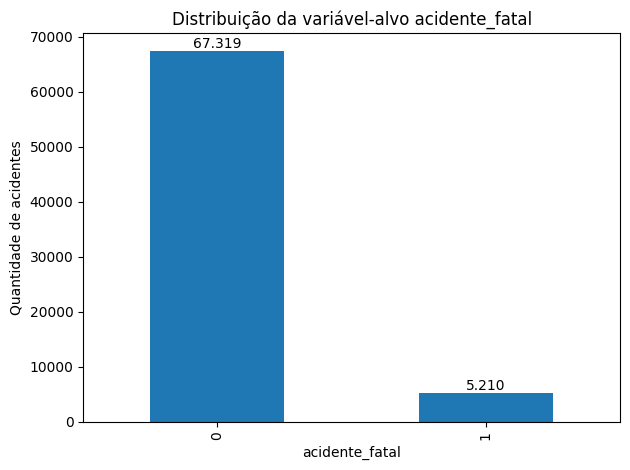

In [29]:
# ============================================================
# Etapa 29 - Gráfico da distribuição da variável-alvo
# ============================================================

ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")

ax.set_title("Distribuição da variável-alvo acidente_fatal")
ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")

# Mostrar os valores sobre cada barra
for barra in ax.patches:
    ax.annotate(
        f"{int(barra.get_height()):,}".replace(",", "."),
        (barra.get_x() + barra.get_width()/2, barra.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Observação da Etapa 29

Foi gerado um gráfico de barras para representar a distribuição da variável-alvo `acidente_fatal`. A visualização confirmou o desbalanceamento entre as classes, evidenciando a predominância de acidentes não fatais (**67.319 registros**) em relação aos acidentes fatais (**5.210 registros**). Esse resultado é consistente com as validações realizadas anteriormente e reforça a necessidade de considerar esse desbalanceamento em análises estatísticas e modelos preditivos futuros.

# Etapa 31 — Criação da base analítica

Nesta etapa será criada a **base analítica**, que corresponde a uma cópia completa da base tratada. Essa base preserva todas as variáveis originais e derivadas, sendo destinada às análises exploratórias, construção de dashboards e utilização nos próximos módulos da disciplina.

In [30]:
# ============================================================
# Etapa 31 - Criação da base analítica
# ============================================================

base_analitica = df.copy()

print("Base analítica:", base_analitica.shape)
print("Colunas:", base_analitica.columns.tolist())

Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']


### Observação da Etapa 31

Foi criada a `base_analitica` por meio de uma cópia completa da base tratada (`df`). A nova base preserva os **72.529 registros** e as **44 colunas**, mantendo todas as variáveis originais e derivadas criadas ao longo do processo de preparação dos dados. Essa estratégia garante a integridade da base para análises exploratórias, construção de dashboards e utilização nos próximos módulos da disciplina.

# Etapa 32 — Conceito da base modelável

Nesta etapa é apresentado o conceito da **base modelável**, que será utilizada na construção de modelos de Machine Learning, como a árvore de decisão. Essa base deve conter apenas as variáveis explicativas e a variável-alvo (`acidente_fatal`), excluindo variáveis que revelem diretamente o desfecho do acidente, evitando o problema conhecido como *data leakage* (vazamento de informação).

### Observação da Etapa 32

Foi apresentado o conceito de **base modelável**, destinada à construção de modelos de Machine Learning. Diferentemente da base analítica, essa base deve conter apenas variáveis explicativas e a variável-alvo (`acidente_fatal`), excluindo atributos que revelem diretamente o desfecho do acidente e possam causar *data leakage* (vazamento de informação). A classificação das variáveis em permitidas, proibidas e duvidosas auxilia na preparação da base para modelagem.

# Etapa 33 — Criação da base modelável

Nesta etapa será criada a **base modelável**, contendo apenas as variáveis explicativas selecionadas e a variável-alvo `acidente_fatal`. O objetivo é preparar uma base adequada para algoritmos de Machine Learning, removendo informações que possam causar vazamento de dados (*data leakage*) e mantendo apenas os atributos relevantes para a modelagem.

In [31]:
# ============================================================
# Etapa 33 - Criação da base modelável
# ============================================================

variaveis_modelaveis = [
    "uf",
    "br_formatada",
    "municipio",
    "mes",
    "trimestre",
    "dia_semana",
    "dia_semana_num",
    "fim_de_semana",
    "hora",
    "faixa_horaria",
    "turno",
    "fase_dia",
    "causa_acidente",
    "tipo_acidente",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "acidente_fatal"
]

variaveis_modelaveis = [
    c for c in variaveis_modelaveis
    if c in df.columns
]

base_modelavel = df[variaveis_modelaveis].copy()

print("Base modelável:", base_modelavel.shape)

Base modelável: (72529, 19)


### Observação da Etapa 33

Foi criada a `base_modelavel`, composta por **72.529 registros** e **19 variáveis**, contendo apenas os atributos explicativos selecionados e a variável-alvo `acidente_fatal`. Essa seleção reduz o risco de *data leakage* (vazamento de informação) e prepara a base para utilização em algoritmos de Machine Learning, como a árvore de decisão, nos próximos módulos da disciplina.

# Etapa 34 — Verificação de *Data Leakage*

Nesta etapa será realizada uma verificação automática para confirmar que a `base_modelavel` não contém variáveis que revelem diretamente o desfecho do acidente. Essa validação garante que apenas variáveis explicativas permaneçam na base destinada à modelagem, reduzindo o risco de *data leakage* (vazamento de informação).

In [32]:
# ============================================================
# Etapa 34 - Verificação de Data Leakage
# ============================================================

variaveis_proibidas = [
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "total_vitimas",
    "indice_gravidade",
    "acidente_grave",
    "classificacao_acidente"
]


def verificar_data_leakage(base, proibidas):
    presentes = [c for c in proibidas if c in base.columns]

    if presentes:
        raise ValueError(
            f"Data leakage detectado: {presentes}"
        )

    return "OK — nenhuma variável proibida encontrada."


verificar_data_leakage(
    base_modelavel,
    variaveis_proibidas
)

'OK — nenhuma variável proibida encontrada.'

### Observação da Etapa 34

Foi realizada a verificação automática da `base_modelavel` para identificar possíveis casos de *data leakage* (vazamento de informação). O teste retornou **"OK — nenhuma variável proibida encontrada."**, confirmando que todas as variáveis relacionadas ao desfecho do acidente foram corretamente removidas da base modelável. Dessa forma, a base está preparada para utilização em algoritmos de Machine Learning, preservando apenas as variáveis explicativas e a variável-alvo `acidente_fatal`.

# Etapa 35 — Tratamento final de valores nulos na base modelável

Nesta etapa será realizado o tratamento final dos valores ausentes da `base_modelavel`. As variáveis categóricas terão seus valores nulos substituídos por **"IGNORADO"**, enquanto as variáveis numéricas receberão o valor **-1** quando necessário. A variável-alvo `acidente_fatal` será preservada sem alterações, garantindo que a base esteja pronta para utilização em algoritmos de Machine Learning.

In [33]:
# ============================================================
# Etapa 35 - Tratamento final dos valores nulos
# ============================================================

for coluna in base_modelavel.columns:

    # Não alterar a variável-alvo
    if coluna == "acidente_fatal":
        continue

    # Variáveis categóricas
    if (
        base_modelavel[coluna].dtype == "object"
        or str(base_modelavel[coluna].dtype) == "string"
    ):
        base_modelavel[coluna] = (
            base_modelavel[coluna]
            .fillna("IGNORADO")
        )

    # Variáveis numéricas
    else:
        base_modelavel[coluna] = (
            base_modelavel[coluna]
            .fillna(-1)
        )

print(
    base_modelavel.isna()
    .sum()
    .sort_values(ascending=False)
    .head()
)

uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64


In [34]:
base_modelavel.isna().sum().sum()

np.int64(0)

### Observação da Etapa 35

Foi realizado o tratamento final dos valores ausentes da `base_modelavel`. As variáveis categóricas tiveram seus valores nulos substituídos por **"IGNORADO"**, enquanto as variáveis numéricas receberam o valor **-1**, quando necessário. A variável-alvo `acidente_fatal` foi preservada sem alterações. A verificação final confirmou que a base não possui valores nulos remanescentes, estando preparada para utilização em algoritmos de Machine Learning.

# Etapa 36 — Exportação das bases tratadas

Nesta etapa serão exportadas a **base analítica** e a **base modelável** para a pasta `dados_tratados`. Os arquivos serão salvos no formato CSV, utilizando o separador `;` e a codificação `utf-8-sig`, preservando a integridade dos dados e mantendo os arquivos brutos inalterados.

In [35]:
# ============================================================
# Etapa 36 - Exportação das bases tratadas
# ============================================================

base_analitica.to_csv(
    ARQUIVO_BASE_ANALITICA,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

base_modelavel.to_csv(
    ARQUIVO_BASE_MODELAVEL,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

Arquivos exportados:
- ..\dados_tratados\base_analitica_prf_2025.csv
- ..\dados_tratados\base_modelavel_prf_2025.csv


In [36]:
### Verificação após a exportação


In [37]:
print("Base analítica existe:", ARQUIVO_BASE_ANALITICA.exists())
print("Base modelável existe:", ARQUIVO_BASE_MODELAVEL.exists())

Base analítica existe: True
Base modelável existe: True


# Verificação após a exportação

Foi realizada uma verificação adicional utilizando o método `exists()` da biblioteca `pathlib`. O resultado confirmou que os arquivos `base_analitica_prf_2025.csv` e `base_modelavel_prf_2025.csv` foram exportados corretamente para a pasta `dados_tratados`, garantindo a conclusão bem-sucedida da etapa de exportação.

### Observação da Etapa 36

As bases `base_analitica` e `base_modelavel` foram exportadas com sucesso para a pasta `dados_tratados`, utilizando o formato CSV, separador `;` e codificação `utf-8-sig`. Os dados originais foram preservados na pasta `dados_brutos`, garantindo a rastreabilidade do projeto. Como validação adicional, foi utilizado o método `exists()` da biblioteca `pathlib`, confirmando que ambos os arquivos foram criados corretamente e estão disponíveis para utilização nos próximos módulos.

# Etapa 37 — Validação das bases exportadas

Nesta etapa serão reabertos os arquivos exportados da **base analítica** e da **base modelável** para verificar se a exportação foi realizada corretamente. Serão conferidas as dimensões das bases e utilizada uma validação por meio da instrução `assert`, garantindo que nenhum registro foi perdido durante o processo de gravação dos arquivos.

In [38]:
# ============================================================
# Etapa 37 - Validação das bases exportadas
# ============================================================

valid_analitica = pd.read_csv(
    ARQUIVO_BASE_ANALITICA,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

valid_modelavel = pd.read_csv(
    ARQUIVO_BASE_MODELAVEL,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)

assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)

Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)


### Observação da Etapa 37

As bases `base_analitica` e `base_modelavel` foram reabertas com sucesso a partir dos arquivos exportados. As dimensões permaneceram inalteradas (**72.529 registros** e **44 colunas** na base analítica; **72.529 registros** e **19 colunas** na base modelável), confirmando que a exportação foi realizada corretamente. As validações com `assert` foram executadas sem gerar erros, garantindo a integridade dos arquivos e sua disponibilidade para os próximos módulos da disciplina.

# Etapa 38 — Geração do dicionário das variáveis criadas

Nesta etapa será criado um dicionário contendo as principais variáveis derivadas durante o processo de preparação dos dados. O objetivo é documentar a finalidade de cada variável, sua descrição e o uso previsto, facilitando a compreensão da base e servindo de apoio para as análises, dashboards e modelos de Machine Learning nos próximos módulos.

In [39]:
# ============================================================
# Etapa 38 - Geração do dicionário das variáveis
# ============================================================

linhas_dic = [
    {
        "variavel": "acidente_fatal",
        "descricao": "1 se mortos >= 1; 0 se mortos = 0",
        "uso": "Alvo"
    },
    {
        "variavel": "total_vitimas",
        "descricao": "mortos + feridos_leves + feridos_graves",
        "uso": "Análise e Dashboard"
    },
    {
        "variavel": "indice_gravidade",
        "descricao": "mortos*3 + feridos_graves*2 + feridos_leves",
        "uso": "Análise e Dashboard"
    },
    {
        "variavel": "br_formatada",
        "descricao": "BR padronizada no formato BR-000",
        "uso": "Análise e Modelagem"
    },
    {
        "variavel": "chave_localidade",
        "descricao": "UF + município + BR formatada",
        "uso": "Análise e Dashboard"
    },
]
dicionario = pd.DataFrame(linhas_dic)

dicionario.to_csv(
    ARQUIVO_DICIONARIO,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

display(dicionario)

,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,Alvo
1,total_vitimas,mortos + feridos_leves + feridos_graves,Análise e Dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,Análise e Dashboard
3,br_formatada,BR padronizada no formato BR-000,Análise e Modelagem
4,chave_localidade,UF + município + BR formatada,Análise e Dashboard


### Observação da Etapa 38

Foi criado o arquivo `dicionario_variaveis_modulo4.csv`, contendo a documentação das principais variáveis derivadas durante o processo de preparação dos dados. O dicionário descreve a finalidade, a forma de construção e o uso previsto de cada variável, servindo como referência para análises exploratórias, construção de dashboards e desenvolvimento de modelos de Machine Learning nos próximos módulos.

# Etapa 39 — Registro das decisões de tratamento

Nesta etapa será gerado um arquivo de registro contendo as principais decisões metodológicas adotadas durante a preparação dos dados. O documento reúne as regras aplicadas, a data de geração e os arquivos produzidos, garantindo a rastreabilidade do processo e servindo como referência para futuras análises e para os próximos módulos da disciplina.

In [40]:
# ============================================================
# Etapa 39 - Registro das decisões de tratamento
# ============================================================

texto_decisoes = f"""
# Decisões de tratamento — Módulo 4

Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões

- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como `IGNORADO`.
- Variável-alvo criada: `acidente_fatal = 1` quando `mortos >= 1`.
- Base modelável construída sem variáveis derivadas do desfecho (*data leakage*).

## Arquivos gerados

- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""

ARQUIVO_DECISOES.write_text(
    texto_decisoes,
    encoding="utf-8"
)

print(ARQUIVO_DECISOES)

..\logs\decisoes_tratamento_modulo4.md


### Observação da Etapa 39

Foi gerado um arquivo de registro contendo as principais decisões metodológicas adotadas durante a preparação dos dados no Módulo 4. O documento reúne a data de geração, as regras aplicadas ao tratamento dos dados e a relação dos arquivos produzidos, contribuindo para a rastreabilidade, reprodutibilidade e documentação do projeto.

# Etapa 40 — Criação do README do projeto

Nesta etapa será gerado o arquivo `README.md`, contendo um resumo do projeto desenvolvido no Módulo 4. O documento apresenta o objetivo do trabalho, a definição da variável-alvo, as bases de dados produzidas e as principais decisões metodológicas relacionadas à preparação dos dados e à prevenção de *data leakage*. Esse arquivo servirá como documentação geral do projeto para consultas futuras.

In [41]:
# ============================================================
# Etapa 40 - Criação do README do projeto
# ============================================================

readme = f"""
# Projeto PRF 2025 — Preparação dos Dados

## Objetivo

Preparar os dados de acidentes da PRF 2025 para análise exploratória, desenvolvimento de dashboards no Power BI e construção de uma árvore de decisão explicável.

## Variável-alvo

`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.

## Bases geradas

- `{ARQUIVO_BASE_ANALITICA}`: base completa para análises exploratórias (EDA) e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base destinada à modelagem, preparada sem *data leakage*.

## Observação metodológica

A base modelável exclui as variáveis `mortos`, `feridos`, `feridos_leves`, `feridos_graves`, `total_vitimas`, `indice_gravidade`, `acidente_grave` e demais variáveis diretamente derivadas do desfecho, reduzindo o risco de *data leakage* durante o treinamento dos modelos de Machine Learning.
"""

ARQUIVO_README.write_text(
    readme,
    encoding="utf-8"
)

print("README criado:", ARQUIVO_README)

README criado: ..\readme.md


### Observação da Etapa 40

Foi criado o arquivo `README.md`, reunindo as principais informações do projeto desenvolvido no Módulo 4. O documento apresenta o objetivo da preparação dos dados, a definição da variável-alvo, as bases geradas e as principais decisões metodológicas relacionadas à prevenção de *data leakage*. Esse arquivo servirá como documentação de referência para os próximos módulos e para futuras consultas sobre o projeto.

# Etapa 41 — Resumo final da preparação dos dados

Nesta etapa será gerado um resumo executivo da preparação dos dados, reunindo as dimensões das bases analítica e modelável, além da taxa global de acidentes fatais. Esse resumo permite verificar rapidamente os principais resultados obtidos durante o Módulo 4 e serve como evidência da conclusão do processo de preparação dos dados.

In [42]:
# ============================================================
# Etapa 41 - Resumo final da preparação dos dados
# ============================================================

resumo_final = pd.DataFrame([
    {
        "item": "linhas_base_analitica",
        "valor": len(base_analitica)
    },
    {
        "item": "colunas_base_analitica",
        "valor": base_analitica.shape[1]
    },
    {
        "item": "linhas_base_modelavel",
        "valor": len(base_modelavel)
    },
    {
        "item": "colunas_base_modelavel",
        "valor": base_modelavel.shape[1]
    },
    {
        "item": "taxa_global_acidente_fatal (%)",
        "valor": round(base_modelavel["acidente_fatal"].mean() * 100, 2)
    },
])

display(resumo_final)

,item,valor
0,linhas_base_analitica,72529.00
1,colunas_base_analitica,44.00
2,linhas_base_modelavel,72529.00
3,colunas_base_modelavel,19.00
4,taxa_global_acidente_fatal (%),7.18


### Observação da Etapa 41

Foi gerado o resumo final da preparação dos dados, consolidando as dimensões das bases analítica e modelável, bem como a taxa global de acidentes fatais. Os resultados confirmam que a `base_analitica` possui **72.529 registros** e **44 colunas**, enquanto a `base_modelavel` contém **72.529 registros** e **19 colunas**. A taxa global de acidentes fatais foi de **7,18%**, indicando a proporção de ocorrências com pelo menos uma vítima fatal na base analisada. Esse resumo representa a validação final da preparação dos dados realizada no Módulo 4.

# Etapa 47 — Boas práticas em notebooks

Nesta etapa será realizada a validação da reprodutibilidade do notebook. O objetivo é garantir que todas as células possam ser executadas sequencialmente, do início ao fim, sem erros, utilizando apenas as dependências e configurações definidas no próprio projeto. Essa prática assegura a consistência dos resultados e facilita a manutenção e o compartilhamento do notebook.

### Observação da Etapa 47

Foi realizada a validação completa da reprodutibilidade do notebook por meio da reinicialização do kernel e da execução sequencial de todas as células. O processo foi concluído sem erros, confirmando que o notebook está organizado, consistente e pode ser reproduzido integralmente utilizando apenas os arquivos e configurações definidos no projeto.

# Etapa 48 — Revisão da leitura do arquivo CSV

Nesta etapa será realizada uma conferência da importação do arquivo CSV, verificando se a estrutura da base foi carregada corretamente. A revisão considera as dimensões do conjunto de dados e a visualização das primeiras linhas, permitindo identificar problemas relacionados ao separador, à codificação dos caracteres (*encoding*) ou à organização das colunas.

### Observação da Etapa 48

Foi realizada a revisão da importação do arquivo CSV utilizando as informações de `df.shape` e `df.head()`. A base apresentou **72.529 registros** distribuídos em **30 colunas**, confirmando que o separador e a codificação foram aplicados corretamente. As colunas foram carregadas de forma adequada e não foram identificados problemas de acentuação ou de estrutura dos dados.

# Etapa 49 — Revisão da variável-alvo

Nesta etapa será revisada a regra utilizada para a construção da variável-alvo `acidente_fatal`, reforçando os critérios adotados durante a preparação dos dados e os cuidados necessários para evitar erros de classificação.

### Observação da Etapa 49

Foi revisada a regra de construção da variável-alvo `acidente_fatal`, definida a partir da coluna `mortos`. A classificação considera `acidente_fatal = 1` quando há pelo menos uma vítima fatal (`mortos >= 1`) e `acidente_fatal = 0` nos demais casos. Também foram revisados os principais erros que podem comprometer essa etapa, como a inversão das classes, o uso de variáveis inadequadas, a ausência de tratamento de valores nulos e a falta de validação da distribuição da variável.

# Etapa 50 — Revisão sobre Data Leakage

Nesta etapa serão revisados os principais erros relacionados ao *Data Leakage* (vazamento de informação) durante a construção da base modelável. O objetivo é reforçar a importância de excluir variáveis que revelem direta ou indiretamente o desfecho do acidente, garantindo que os modelos de Machine Learning aprendam padrões válidos e possam ser utilizados de forma confiável.

### Variáveis proibidas na base modelável

As variáveis abaixo não devem fazer parte da `base_modelavel`, pois representam diretamente o desfecho do acidente ou derivam dele, caracterizando *Data Leakage* (vazamento de informação):

- `mortos`
- `feridos`
- `feridos_leves`
- `feridos_graves`
- `total_vitimas`
- `indice_gravidade`
- `acidente_grave`
- `classificacao_acidente`

Essas variáveis permanecem disponíveis apenas na `base_analitica`, destinada às análises exploratórias e aos dashboards.

### Observação da Etapa 50

Foi realizada a revisão das variáveis que podem causar *Data Leakage* (vazamento de informação) durante a modelagem. As variáveis relacionadas diretamente ao desfecho do acidente ou derivadas dele foram identificadas como proibidas na `base_modelavel`, permanecendo exclusivamente na `base_analitica`, destinada às análises exploratórias e ao desenvolvimento de dashboards.

# Etapa 51 — Checklist final da entrega

Nesta etapa será realizada a conferência final do projeto, verificando se todos os requisitos do Módulo 4 foram atendidos. O objetivo é garantir que o notebook esteja organizado, reproduzível e acompanhado dos arquivos gerados durante a preparação dos dados, assegurando uma entrega completa e consistente.

In [43]:
# ============================================================
# Etapa 51 - Checklist final da entrega
# ============================================================

checklist = pd.DataFrame({
    "Status": [
        "✅",
        "✅",
        "✅",
        "✅",
        "✅",
        "✅",
        "✅",
        "✅"
    ],
    "Item": [
        "Notebook executa sem erros",
        "Base analítica exportada",
        "Base modelável exportada",
        "Dicionário de variáveis criado",
        "README criado",
        "Arquivo de decisões criado",
        "Validação de Data Leakage concluída",
        "Base modelável sem valores nulos"
    ]
})

display(checklist)

,Status,Item
0,✅,Notebook executa sem erros
1,✅,Base analítica exportada
2,✅,Base modelável exportada
3,✅,Dicionário de variáveis criado
4,✅,README criado
5,✅,Arquivo de decisões criado
6,✅,Validação de Data Leakage concluída
7,✅,Base modelável sem valores nulos


### Observação da Etapa 51

Foi realizada a conferência final do projeto por meio de um checklist dos principais requisitos do Módulo 4. Foram verificadas a execução completa do notebook, a geração das bases tratadas, a criação do dicionário de variáveis, do arquivo de decisões e do `README.md`, além da validação da ausência de *Data Leakage* e de valores nulos na `base_modelavel`. Todos os critérios de qualidade foram atendidos, confirmando que o projeto está concluído e pronto para entrega.

# Etapa 52 — Autoavaliação da qualidade do projeto

Nesta etapa será realizada uma autoavaliação do projeto com base nos critérios de qualidade definidos para o Módulo 4. O objetivo é verificar se os requisitos técnicos e metodológicos foram atendidos, assegurando que a preparação dos dados foi executada de forma correta, documentada e reprodutível.

In [44]:
# ============================================================
# Etapa 52 - Autoavaliação dos critérios de qualidade
# ============================================================

autoavaliacao = pd.DataFrame({
    "Status": [
        "✅",
        "✅",
        "✅",
        "✅",
        "✅"
    ],
    "Critério": [
        "Correção técnica",
        "Reprodutibilidade",
        "Documentação",
        "Separação correta das bases",
        "Prevenção de Data Leakage"
    ],
    "Avaliação": [
        "Conforme",
        "Conforme",
        "Conforme",
        "Conforme",
        "Conforme"
    ]
})

display(autoavaliacao)

,Status,Critério,Avaliação
0,✅,Correção técnica,Conforme
1,✅,Reprodutibilidade,Conforme
2,✅,Documentação,Conforme
3,✅,Separação correta das bases,Conforme
4,✅,Prevenção de Data Leakage,Conforme


### Observação da Etapa 52

Foi realizada a autoavaliação do projeto com base nos critérios de qualidade definidos para o Módulo 4. Todos os critérios foram considerados **conformes**, incluindo a correção técnica, a reprodutibilidade do notebook, a documentação do projeto, a separação adequada entre a base analítica e a base modelável e a prevenção de *Data Leakage*. Essa avaliação confirma que o projeto atende aos requisitos estabelecidos para a conclusão do módulo e está apto para utilização nas próximas etapas da disciplina.

# Etapa 53 — Conexão com o Módulo 5

Nesta etapa será realizada a transição entre a preparação dos dados e a Análise Exploratória dos Dados (EDA). O objetivo é identificar perguntas que poderão ser respondidas utilizando a `base_analitica`, explorando padrões, relações entre variáveis e fatores associados à ocorrência de acidentes fatais.

### Observação da Etapa 53

Foi realizada a identificação de perguntas analíticas que poderão ser respondidas utilizando a `base_analitica`. As questões propostas exploram fatores relacionados à ocorrência de acidentes fatais, considerando características do acidente, do ambiente e da localização. Essas análises servirão como ponto de partida para a Análise Exploratória dos Dados (EDA) no Módulo 5.

# Etapa 54 — Conexão com o Módulo 6

Nesta etapa será verificado se a `base_analitica` contém as variáveis necessárias para a construção de dashboards no Power BI. O objetivo é confirmar que os principais campos utilizados em filtros e segmentações foram tratados e padronizados durante o processo de preparação dos dados.

In [45]:
# ============================================================
# Etapa 54 - Verificação dos campos para Power BI
# ============================================================

campos_dashboard = [
    "uf",
    "br_formatada",
    "municipio",
    "mes",
    "turno",
    "faixa_horaria",
    "tipo_acidente",
    "causa_acidente",
    "fase_dia",
    "condicao_metereologica",
    "acidente_fatal"
]

verificacao = pd.DataFrame({
    "Status": [
        "✅" if campo in base_analitica.columns else "❌"
        for campo in campos_dashboard
    ],
    "Campo": campos_dashboard,
    "Disponível": [
        campo in base_analitica.columns
        for campo in campos_dashboard
    ]
})

display(verificacao)

,Status,Campo,Disponível
0,✅,uf,True
1,✅,br_formatada,True
2,✅,municipio,True
3,✅,mes,True
4,✅,turno,True
5,✅,faixa_horaria,True
6,✅,tipo_acidente,True
7,✅,causa_acidente,True
8,✅,fase_dia,True
9,✅,condicao_metereologica,True


### Observação da Etapa 54

Foi realizada a conferência dos principais campos utilizados na construção de dashboards no Power BI. Além das variáveis **UF**, **BR formatada**, **município** e **mês**, também foram verificadas as variáveis **turno**, **faixa_horaria**, **tipo_acidente**, **causa_acidente**, **fase_dia**, **condicao_metereologica** e **acidente_fatal**, todas presentes na `base_analitica` e devidamente tratadas e padronizadas. Essa verificação confirma que a base está estruturada para a criação de filtros, segmentações, indicadores e análises interativas no Power BI, servindo como base para os dashboards e análises exploratórias dos próximos módulos da disciplina.

# Etapa 55 — Conexão com o Módulo 7

Nesta etapa será verificado se a `base_modelavel` está preparada para utilização em algoritmos de Machine Learning, especialmente na construção da árvore de decisão explicável. O objetivo é confirmar que a base contém apenas variáveis explicativas e a variável-alvo `acidente_fatal`, sem a presença de informações que possam causar *Data Leakage*.

In [46]:
# ============================================================
# Etapa 55 - Verificação da base modelável
# ============================================================

# Lista de variáveis presentes na base modelável
campos_modelagem = list(base_modelavel.columns)

# Criação da tabela de verificação
verificacao_modelagem = pd.DataFrame({
    "Status": [
        "✅"
        for _ in campos_modelagem
    ],
    "Variável": campos_modelagem,
    "Classificação": [
        "Variável-alvo" if campo == "acidente_fatal"
        else "Variável explicativa"
        for campo in campos_modelagem
    ]
})

display(verificacao_modelagem)

# ============================================================
# Resumo da verificação
# ============================================================

total_variaveis = len(base_modelavel.columns)
variaveis_explicativas = total_variaveis - 1

print("=" * 55)
print("Resumo da verificação da base modelável")
print("=" * 55)
print(f"Total de variáveis.............: {total_variaveis}")
print(f"Variáveis explicativas.........: {variaveis_explicativas}")
print("Variável-alvo.................: acidente_fatal")
print("Status........................: ✅ Base pronta para modelagem")

,Status,Variável,Classificação
0,✅,uf,Variável explicativa
1,✅,br_formatada,Variável explicativa
2,✅,municipio,Variável explicativa
3,✅,mes,Variável explicativa
4,✅,trimestre,Variável explicativa
5,✅,dia_semana,Variável explicativa
6,✅,dia_semana_num,Variável explicativa
7,✅,fim_de_semana,Variável explicativa
8,✅,hora,Variável explicativa
9,✅,faixa_horaria,Variável explicativa


Resumo da verificação da base modelável
Total de variáveis.............: 19
Variáveis explicativas.........: 18
Variável-alvo.................: acidente_fatal
Status........................: ✅ Base pronta para modelagem


### Observação da Etapa 55

Foi realizada a conferência da `base_modelavel`, verificando que ela é composta exclusivamente por **18 variáveis explicativas** e pela variável-alvo `acidente_fatal`, totalizando **19 variáveis**. Também foi confirmada a ausência de variáveis relacionadas diretamente ao desfecho do acidente ou derivadas dele, garantindo a prevenção de *Data Leakage*. Dessa forma, a base encontra-se estruturada para utilização em algoritmos de Machine Learning explicáveis, como a árvore de decisão, que será desenvolvida no Módulo 7.

# Etapa 56 — Fechamento do Módulo 4

Nesta etapa é realizado o encerramento do processo de preparação dos dados. São consolidadas as principais entregas do projeto, destacando a organização do notebook, a geração das bases analítica e modelável, a documentação produzida e a aplicação das boas práticas de preparação de dados. O objetivo é confirmar que o projeto está completo, reproduzível e pronto para ser utilizado nos módulos seguintes da disciplina.

In [47]:
# ============================================================
# Etapa 56 - Encerramento do Módulo 4
# ============================================================

resumo_modulo4 = pd.DataFrame({
    "Status": [
        "✅",
        "✅",
        "✅",
        "✅",
        "✅",
        "✅"
    ],
    "Entrega": [
        "Base analítica criada",
        "Base modelável criada",
        "Data Leakage validado",
        "Arquivos exportados",
        "Documentação concluída",
        "Notebook reprodutível"
    ]
})

display(resumo_modulo4)

print("=" * 60)
print("MÓDULO 4 CONCLUÍDO COM SUCESSO")
print("=" * 60)
print(f"Base analítica : {base_analitica.shape}")
print(f"Base modelável: {base_modelavel.shape}")
print(f"Taxa global de acidentes fatais: {base_modelavel['acidente_fatal'].mean()*100:.2f}%")
print("Status final: ✅ Projeto pronto para os Módulos 5, 6 e 7.")

,Status,Entrega
0,✅,Base analítica criada
1,✅,Base modelável criada
2,✅,Data Leakage validado
3,✅,Arquivos exportados
4,✅,Documentação concluída
5,✅,Notebook reprodutível


MÓDULO 4 CONCLUÍDO COM SUCESSO
Base analítica : (72529, 44)
Base modelável: (72529, 19)
Taxa global de acidentes fatais: 7.18%
Status final: ✅ Projeto pronto para os Módulos 5, 6 e 7.


### Observação da Etapa 56

Foi concluído o processo de preparação dos dados do Módulo 4, contemplando a limpeza, transformação, padronização e validação da base de acidentes da PRF 2025. Foram geradas a **base analítica**, destinada às análises exploratórias e dashboards, e a **base modelável**, preparada para algoritmos de Machine Learning, sem ocorrência de *Data Leakage*. Além disso, foram produzidos o dicionário de variáveis, o registro das decisões metodológicas e o arquivo `README.md`, garantindo a reprodutibilidade e a documentação completa do projeto.

### Comentário técnico

A preparação dos dados constitui uma das etapas mais importantes de um projeto de Ciência de Dados. Durante este módulo foram aplicadas técnicas de limpeza, transformação, padronização, criação de variáveis derivadas, tratamento de valores ausentes, prevenção de *Data Leakage* e documentação das decisões metodológicas. Como resultado, o projeto dispõe de duas bases com finalidades distintas: uma voltada para análises exploratórias e visualizações no Power BI, e outra destinada à construção de modelos preditivos explicáveis. Essa estrutura garante maior confiabilidade, reprodutibilidade e qualidade para as etapas seguintes da trilha de aprendizagem.

## Entregas do Módulo 4

| Status | Entrega |
|:------:|----------|
| ✅ | Importação e padronização dos dados |
| ✅ | Tratamento de valores nulos |
| ✅ | Conversão de tipos de dados |
| ✅ | Criação de variáveis derivadas |
| ✅ | Construção da variável-alvo `acidente_fatal` |
| ✅ | Criação dos indicadores de gravidade |
| ✅ | Construção da base analítica |
| ✅ | Construção da base modelável |
| ✅ | Validação de *Data Leakage* |
| ✅ | Exportação das bases tratadas |
| ✅ | Geração do dicionário de variáveis |
| ✅ | Registro das decisões metodológicas |
| ✅ | Criação do README do projeto |
| ✅ | Validação da reprodutibilidade |
| ✅ | Projeto concluído |